# Retail & E-Commerce Business Analytics

## Exploratory Data Analysis (EDA)

This notebook explores the master dataset to identify sales trends, customer behavior, product performance, seller performance, delivery efficiency, payment preferences, and customer satisfaction.

The objective is to answer real business questions through data visualization and statistical analysis, helping stakeholders make informed business decisions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [10]:
master_df = pd.read_csv("master_dataset.csv")

In [13]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_creation_date",
    "review_answer_timestamp",
    "shipping_limit_date"
]

for column in date_columns:
    master_df[column] = pd.to_datetime(
        master_df[column],
        format="mixed",
        errors="coerce"
    )

In [19]:
master_df.shape

(119143, 40)

## Business KPI Section

#### 1. How much total revenue did the company generate?

In [82]:
print(f"Total Revenue : ₹ {master_df['price'].sum():,.2f}")

Total Revenue : ₹ 14,273,699.65


#### 2. How many orders were placed?

In [84]:
print("Total Orders :", master_df["order_id"].nunique())

Total Orders : 99441


#### 3. How many unique customers made purchases?

In [34]:
print("Unique Customers :", master_df["customer_unique_id"].nunique())

Unique Customers : 96096


#### 4. How many sellers are registered?

In [44]:
print("Total Sellers :", master_df["seller_id"].nunique())

Total Sellers : 3095


#### 5. How many products are available?

In [42]:
print("Total Products :", master_df["product_id"].nunique())

Total Products : 32951


#### 6. Average Order Value

In [47]:
aov = (
    master_df["price"].sum()
    / master_df["order_id"].nunique()
)

print(f"Average Order Value : ₹ {aov:.2f}")

Average Order Value : ₹ 143.54


#### 7. KPI 

In [49]:
kpi = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Unique Customers",
        "Total Sellers",
        "Total Products",
        "Average Order Value"
    ],

    "Value": [
        round(master_df["price"].sum(),2),
        master_df["order_id"].nunique(),
        master_df["customer_unique_id"].nunique(),
        master_df["seller_id"].nunique(),
        master_df["product_id"].nunique(),
        round(aov,2)
    ]
})

kpi

,Metric,Value
0,Total Revenue,14273699.65
1,Total Orders,99441.00
2,Unique Customers,96096.00
3,Total Sellers,3095.00
4,Total Products,32951.00
5,Average Order Value,143.54


# Sales Analysis

This section analyzes revenue trends, order volume, and sales performance over time to identify business growth patterns and seasonal trends.

#### 1. How has monthly revenue changed over time?

In [92]:
monthly_sales = (
    master_df.groupby(["Year", "Month"])["price"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Year,Month,price
0,2016,9,267.36
1,2016,10,51068.92
2,2016,12,10.90
3,2017,1,129895.32
4,2017,2,262013.86


Monthly revenue analysis helps identify growth trends, seasonal demand, and periods of high or low sales performance.

In [94]:
monthly_sales["Year_Month"] = (
    monthly_sales["Year"].astype(str)
    + "-"
    + monthly_sales["Month"].astype(str)
)

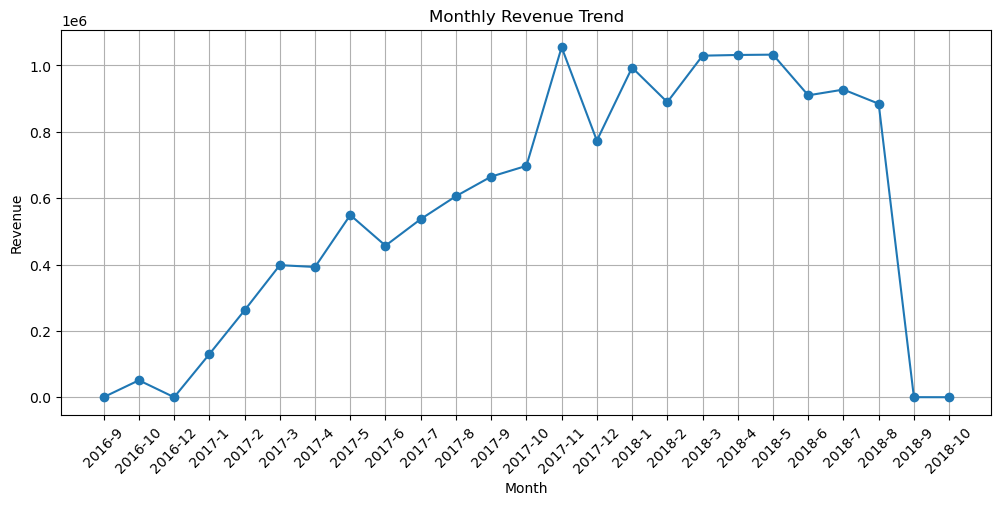

In [96]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales["Year_Month"],
    monthly_sales["price"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

Observation

• Revenue increased steadily during 2017.

• Highest revenue was recorded in November 2017.

• Sales declined after the peak season.

#### 2. Which months generated the highest revenue?


In [67]:
monthly_sales.sort_values(
    by="price",
    ascending=False
).head(10)

,Year,Month,price
13,2017,11,1055072.10
19,2018,5,1032699.42
18,2018,4,1031717.62
17,2018,3,1029589.67
15,2018,1,993701.49
21,2018,7,927401.38
20,2018,6,910053.03
16,2018,2,889512.29
22,2018,8,884731.52
14,2017,12,773574.02


#### 3. Which year generated the highest revenue?

In [71]:
yearly_sales = (
    master_df.groupby("Year")["price"]
    .sum()
    .reset_index()
)

yearly_sales

,Year,price
0,2016,51347.18
1,2017,6522801.05
2,2018,7699551.42


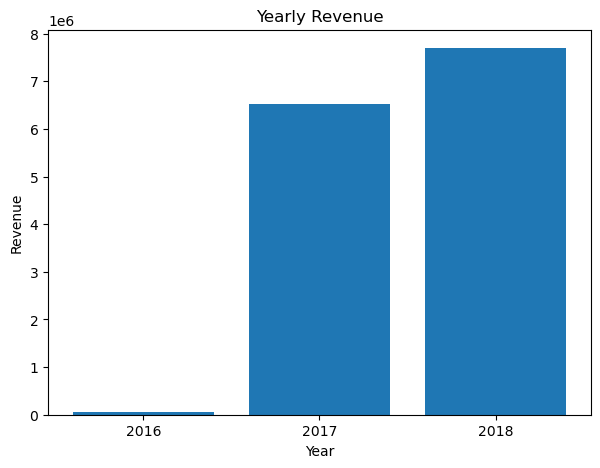

In [73]:
plt.figure(figsize=(7,5))

plt.bar(
    yearly_sales["Year"].astype(str),
    yearly_sales["price"]
)

plt.title("Yearly Revenue")

plt.xlabel("Year")

plt.ylabel("Revenue")

plt.show()

#### 4. How many orders were placed every month?

In [114]:
monthly_orders = (
    master_df.groupby(["Year","Month"])["order_id"]
    .nunique()
    .reset_index()
)

monthly_orders

,Year,Month,order_id
0,2016,9,4
1,2016,10,324
2,2016,12,1
3,2017,1,800
4,2017,2,1780
5,2017,3,2682
6,2017,4,2404
7,2017,5,3700
8,2017,6,3245
9,2017,7,4026


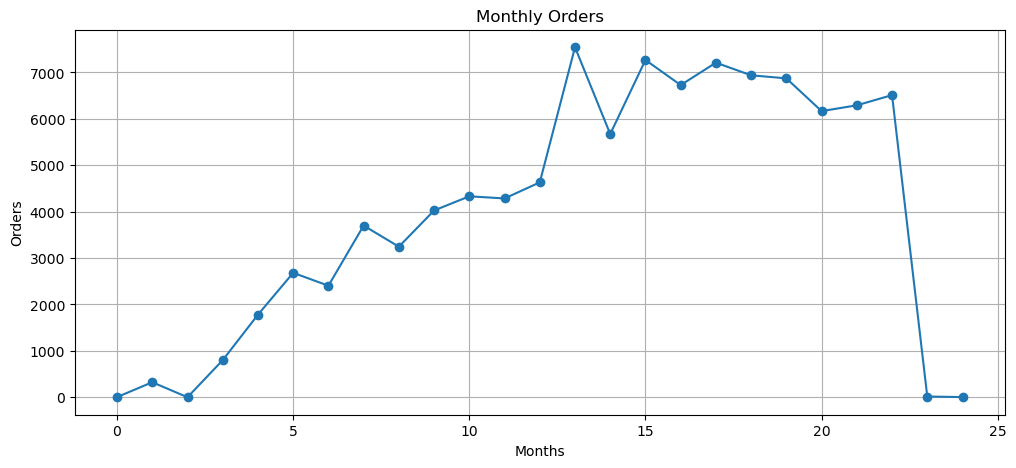

In [116]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_orders.index,
    monthly_orders["order_id"],
    marker="o"
)

plt.title("Monthly Orders")

plt.xlabel("Months")

plt.ylabel("Orders")

plt.grid(True)

plt.show()

# Customer Analysis

This section analyzes customer distribution, purchasing behavior, and geographical insights to better understand the company's customer base.

#### 1. Which states have the highest number of customers?

In [120]:
customers_by_state = (
    master_df.groupby("customer_state")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

customers_by_state.head(10)

,customer_state,customer_unique_id
0,SP,40302
1,RJ,12384
2,MG,11259
3,RS,5277
4,PR,4882
5,SC,3534
6,BA,3277
7,DF,2075
8,ES,1964
9,GO,1952


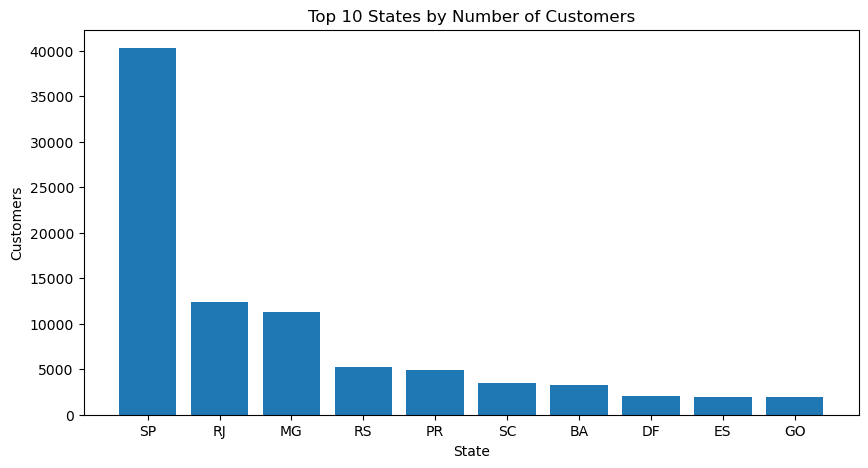

In [122]:
plt.figure(figsize=(10,5))

plt.bar(
    customers_by_state["customer_state"][:10],
    customers_by_state["customer_unique_id"][:10]
)

plt.title("Top 10 States by Number of Customers")

plt.xlabel("State")

plt.ylabel("Customers")

plt.show()

#### 2. Which states generated the highest revenue?

In [125]:
revenue_state = (
    master_df.groupby("customer_state")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

revenue_state.head(10)

,customer_state,price
0,SP,5477008.74
1,RJ,1921752.53
2,MG,1645847.27
3,RS,791716.84
4,PR,708794.22
5,BA,543243.99
6,SC,539896.20
7,DF,315122.29
8,GO,313198.27
9,ES,284771.30


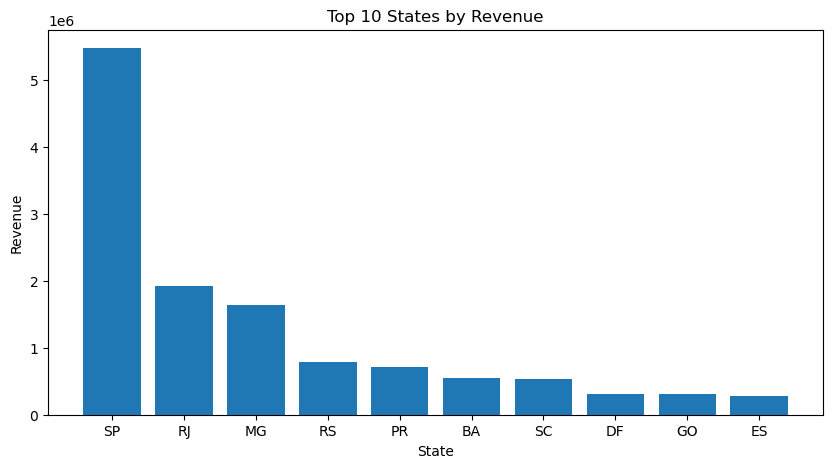

In [127]:
plt.figure(figsize=(10,5))

plt.bar(
    revenue_state["customer_state"][:10],
    revenue_state["price"][:10]
)

plt.title("Top 10 States by Revenue")

plt.xlabel("State")

plt.ylabel("Revenue")

plt.show()

#### 4. Which cities generated the highest revenue?

In [130]:
city_revenue = (
    master_df.groupby("customer_city")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

city_revenue.head(10)

,customer_city,price
0,sao paulo,2020902.59
1,rio de janeiro,1036314.55
2,belo horizonte,368768.85
3,brasilia,314328.80
4,curitiba,219071.05
5,salvador,197445.32
6,campinas,197304.24
7,porto alegre,196867.42
8,guarulhos,155465.31
9,niteroi,133096.16


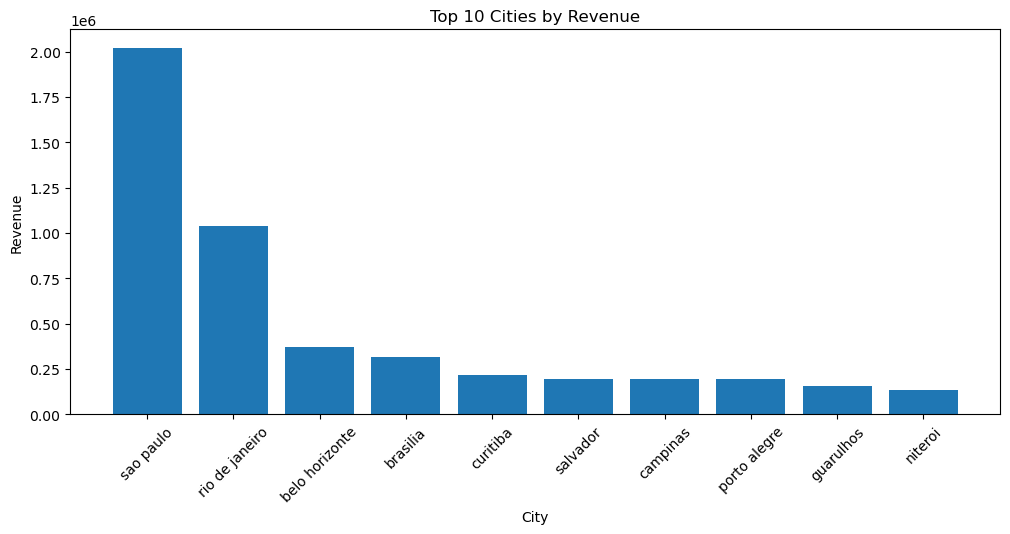

In [132]:
plt.figure(figsize=(12,5))

plt.bar(
    city_revenue["customer_city"][:10],
    city_revenue["price"][:10]
)

plt.title("Top 10 Cities by Revenue")

plt.xlabel("City")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

#### 5. Which cities have the highest number of customers?

In [135]:
city_customers = (
    master_df.groupby("customer_city")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

city_customers.head(10)

,customer_city,customer_unique_id
0,sao paulo,14984
1,rio de janeiro,6620
2,belo horizonte,2672
3,brasilia,2069
4,curitiba,1465
5,campinas,1398
6,porto alegre,1326
7,salvador,1209
8,guarulhos,1153
9,sao bernardo do campo,908


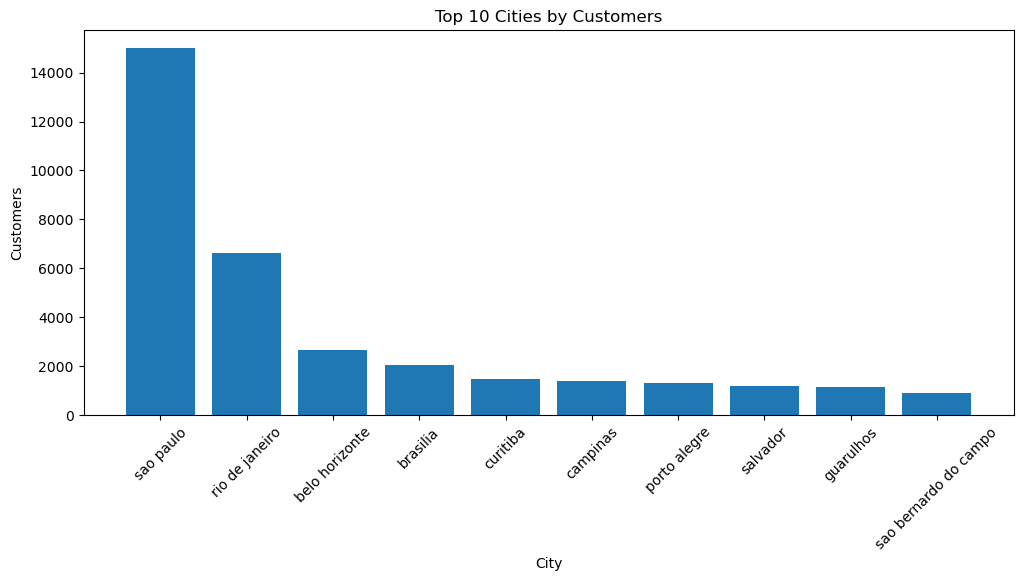

In [137]:
plt.figure(figsize=(12,5))

plt.bar(
    city_customers["customer_city"][:10],
    city_customers["customer_unique_id"][:10]
)

plt.title("Top 10 Cities by Customers")

plt.xlabel("City")

plt.ylabel("Customers")

plt.xticks(rotation=45)

plt.show()

#### 6. Which customers placed the most orders?

In [142]:
repeat_customers = (
    master_df.groupby("customer_unique_id")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

repeat_customers.head(10)

,customer_unique_id,order_id
0,8d50f5eadf50201ccdcedfb9e2ac8455,17
1,3e43e6105506432c953e165fb2acf44c,9
2,6469f99c1f9dfae7733b25662e7f1782,7
3,ca77025e7201e3b30c44b472ff346268,7
4,1b6c7548a2a1f9037c1fd3ddfed95f33,7
5,12f5d6e1cbf93dafd9dcc19095df0b3d,6
6,de34b16117594161a6a89c50b289d35a,6
7,63cfc61cee11cbe306bff5857d00bfe4,6
8,f0e310a6839dce9de1638e0fe5ab282a,6
9,47c1a3033b8b77b3ab6e109eb4d5fdf3,6


## Product Analysis

This section analyzes product categories and sales performance to identify the products that contribute the most to business revenue.

#### 1. Which product categories generate the highest revenue?

In [148]:
category_sales = (
    master_df.groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

category_sales

,product_category_name_english,price
0,health_beauty,1301947.97
1,watches_gifts,1254322.95
2,bed_bath_table,1107249.09
3,sports_leisure,1029603.88
4,computers_accessories,950053.69
5,furniture_decor,772096.17
6,housewares,668880.94
7,cool_stuff,664637.13
8,auto,618395.50
9,garden_tools,519473.33


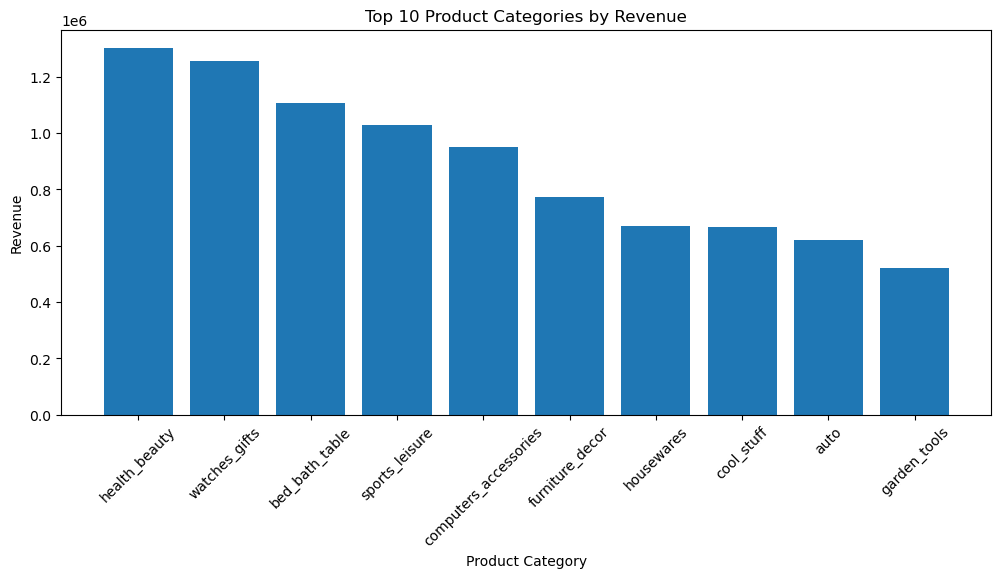

In [150]:
plt.figure(figsize=(12,5))

plt.bar(
    category_sales["product_category_name_english"],
    category_sales["price"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Product Categories by Revenue")

plt.xlabel("Product Category")

plt.ylabel("Revenue")

plt.show()

The highest revenue comes from a few product categories, indicating that these categories are the major contributors to overall sales.

#### 2. Which product categories received the most orders?

In [156]:
category_orders = (
    master_df.groupby("product_category_name_english")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

category_orders

,product_category_name_english,order_id
0,bed_bath_table,9417
1,health_beauty,8836
2,sports_leisure,7720
3,computers_accessories,6689
4,furniture_decor,6449
5,housewares,5884
6,watches_gifts,5624
7,telephony,4199
8,auto,3897
9,toys,3886


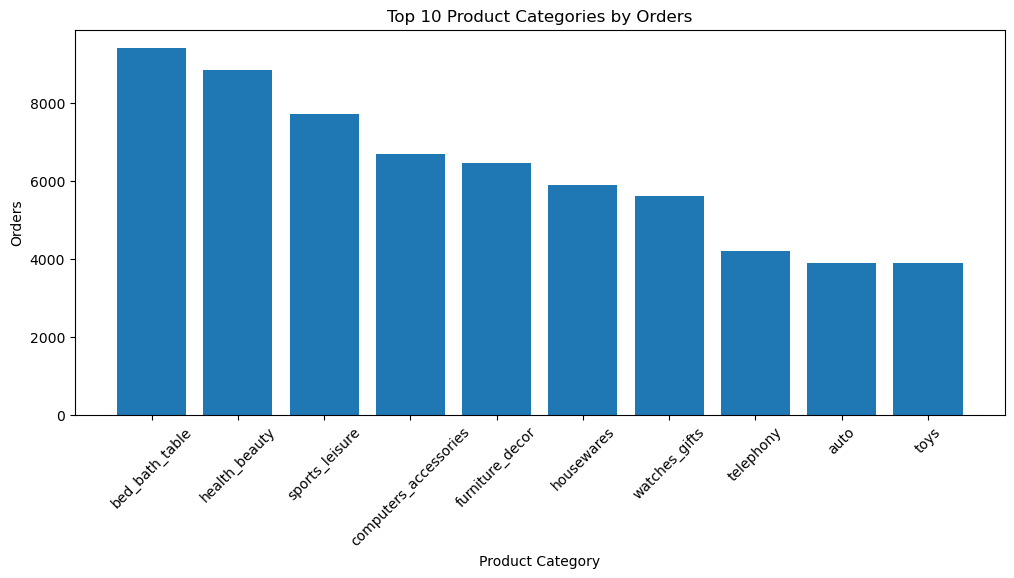

In [158]:
plt.figure(figsize=(12,5))

plt.bar(
    category_orders["product_category_name_english"],
    category_orders["order_id"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Product Categories by Orders")

plt.xlabel("Product Category")

plt.ylabel("Orders")

plt.show()

Some categories receive a larger number of orders, showing higher customer demand.

#### 3. Which products are the most expensive?

In [162]:
expensive_products = (
    master_df[
        ["product_id",
         "product_category_name_english",
         "price"]
    ]
    .sort_values(
        by="price",
        ascending=False
    )
    .head(10)
)

expensive_products

,product_id,product_category_name_english,price
26500,489ae2aa008f021502940f251d4cce7f,housewares,6735.00
33966,69c590f7ffc7bf8db97190b6cb6ed62e,computers,6729.00
4161,1bdf5e6731585cf01aa8169c7028d6ad,art,6499.00
63850,a6492cc69376c469ab6f61d8f44de961,small_appliances,4799.00
48345,c3ed642d592594bb648ff4a04cee2747,small_appliances,4690.00
48361,259037a6a41845e455183f89c5035f18,computers,4590.00
13890,a1beef8f3992dbd4cd8726796aa69c53,musical_instruments,4399.87
23265,6cdf8fc1d741c76586d8b6b15e9eef30,consoles_games,4099.99
3196,dd113cb02b2af9c8e5787e8f1f0722f6,sports_leisure,4059.00
68256,6902c1962dd19d540807d0ab8fade5c6,watches_gifts,3999.90


The dataset contains a few high-priced products that contribute significantly to individual transaction values.

#### 4. What is the average product price by category?

In [166]:
avg_price = (
    master_df.groupby("product_category_name_english")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

avg_price

,product_category_name_english,price
0,computers,1103.689136
1,small_appliances_home_oven_and_coffee,627.509103
2,home_appliances_2,457.529481
3,agro_industry_and_commerce,332.706151
4,musical_instruments,293.398651
5,small_appliances,286.297248
6,fixed_telephony,226.989890
7,construction_tools_safety,210.942261
8,watches_gifts,201.886842
9,air_conditioning,185.305894


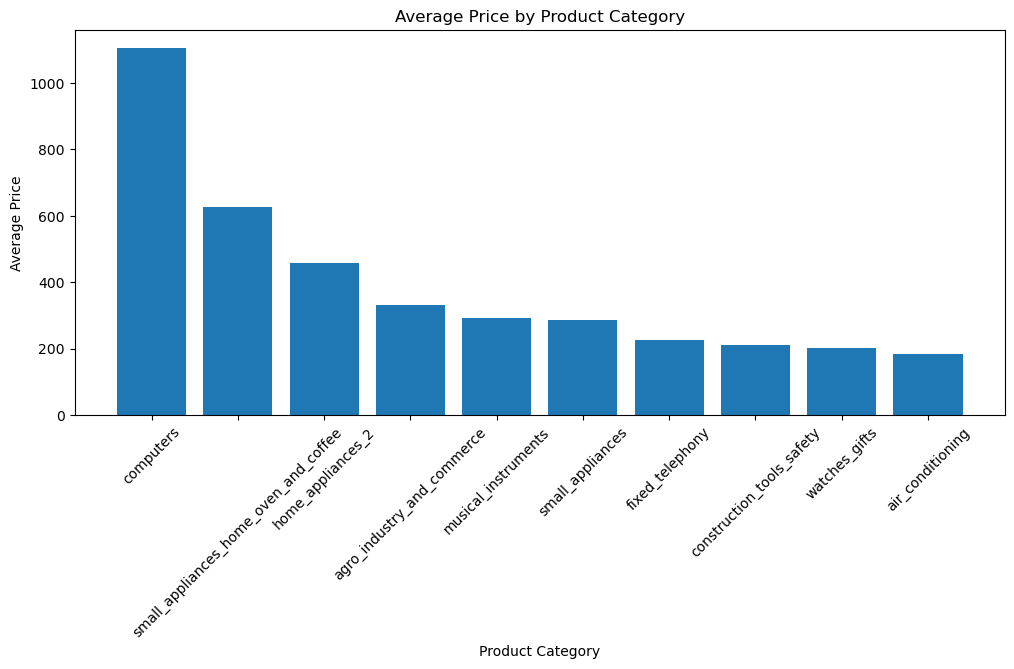

In [168]:
plt.figure(figsize=(12,5))

plt.bar(
    avg_price["product_category_name_english"],
    avg_price["price"]
)

plt.xticks(rotation=45)

plt.title("Average Price by Product Category")

plt.xlabel("Product Category")

plt.ylabel("Average Price")

plt.show()

Some product categories have a higher average selling price, indicating premium-priced products.

## Payment Analysis

This section analyzes customer payment preferences and payment values to understand purchasing behavior and payment trends.

#### 1. Which payment method is used the most?

In [173]:
payment_type = (
    master_df.groupby("payment_type")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

payment_type

,payment_type,order_id
0,credit_card,76505
1,boleto,19784
2,voucher,3866
3,debit_card,1528
4,not_defined,3


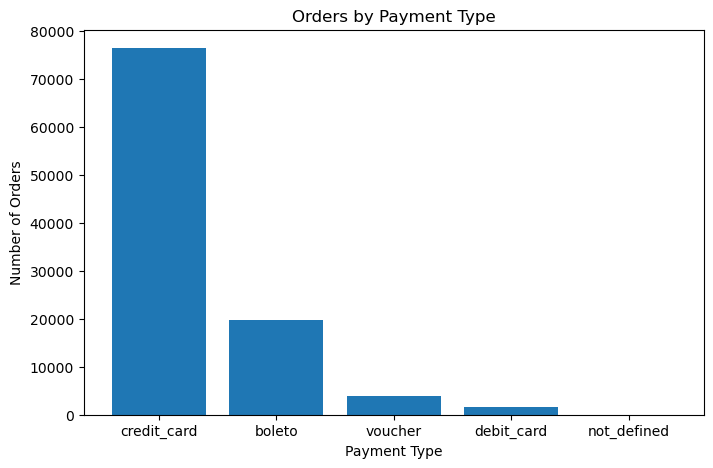

In [175]:
plt.figure(figsize=(8,5))

plt.bar(
    payment_type["payment_type"],
    payment_type["order_id"]
)

plt.title("Orders by Payment Type")

plt.xlabel("Payment Type")

plt.ylabel("Number of Orders")

plt.show()

Most customers prefer a few payment methods, indicating their popularity for online purchases.

#### 2. Which payment method generated the highest payment value?

In [181]:
payment_value = (
    master_df.groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

payment_value

,payment_type,payment_value
0,credit_card,15775450.54
1,boleto,4110920.74
2,voucher,435917.84
3,debit_card,257374.89
4,not_defined,0.00


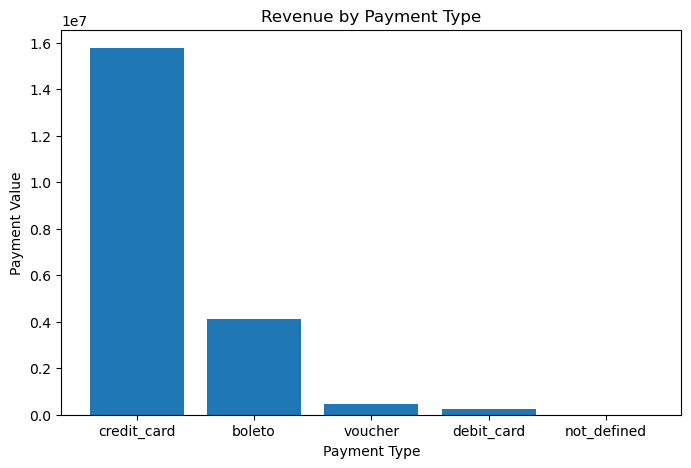

In [183]:
plt.figure(figsize=(8,5))

plt.bar(
    payment_value["payment_type"],
    payment_value["payment_value"]
)

plt.title("Revenue by Payment Type")

plt.xlabel("Payment Type")

plt.ylabel("Payment Value")

plt.show()

The leading payment methods contribute the largest share of total payment value.

#### 3. How many installments do customers usually choose?

In [187]:
installments = (
    master_df.groupby("payment_installments")["order_id"]
    .nunique()
    .reset_index()
)

installments.head(10)

,payment_installments,order_id
0,0.0,2
1,1.0,49060
2,2.0,12389
3,3.0,10443
4,4.0,7088
5,5.0,5234
6,6.0,3916
7,7.0,1623
8,8.0,4253
9,9.0,644


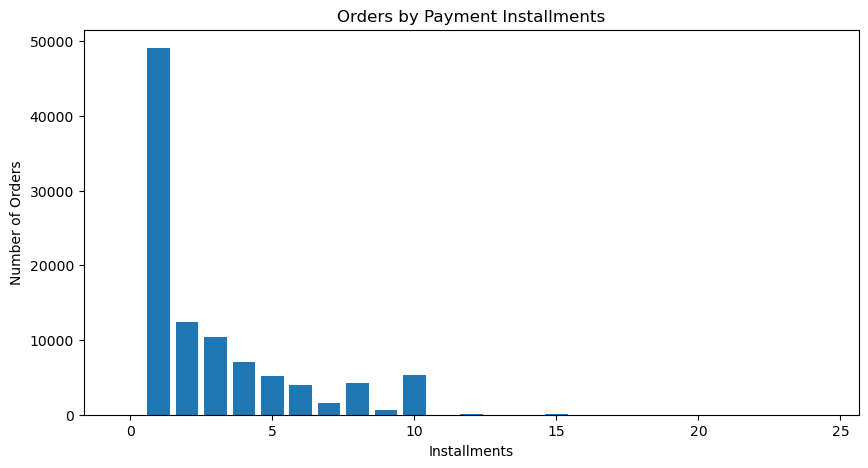

In [189]:
plt.figure(figsize=(10,5))

plt.bar(
    installments["payment_installments"],
    installments["order_id"]
)

plt.title("Orders by Payment Installments")

plt.xlabel("Installments")

plt.ylabel("Number of Orders")

plt.show()

Most customers prefer lower installment options, while higher installment plans are less common.

In [203]:
# Create delivery-related features

master_df["delivery_time_days"] = (
    master_df["order_delivered_customer_date"]
    - master_df["order_purchase_timestamp"]
).dt.days

master_df["delivery_delay_days"] = (
    master_df["order_delivered_customer_date"]
    - master_df["order_estimated_delivery_date"]
).dt.days

## Delivery & Logistics Analysis

This section analyzes delivery performance, shipping delays, and their impact on customer experience.

#### 1. What is the average delivery time?

In [205]:
print(
    f"Average Delivery Time : {master_df['delivery_time_days'].mean():.2f} days"
)

Average Delivery Time : 12.02 days


#### 2. Which states have the highest average delivery time?

In [207]:
state_delivery = (
    master_df.groupby("customer_state")["delivery_time_days"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

state_delivery.head(10)

,customer_state,delivery_time_days
0,RR,27.826087
1,AP,27.662651
2,AM,26.064706
3,AL,24.128090
4,PA,23.268004
5,MA,21.191981
6,SE,20.886010
7,CE,20.344415
8,AC,20.170213
9,PB,20.107372


#### 3. How many orders were delivered late?

In [212]:
late_orders = (
    master_df["delivery_delay_days"] > 0
).sum()

print("Late Orders :", late_orders)

Late Orders : 7559


Only a small percentage of orders were delivered after the estimated delivery date.

#### 4. Does delivery delay affect customer review scores?

In [220]:
delay_review = (
    master_df.groupby("delivery_delay_days")["review_score"]
    .mean()
    .reset_index()
)

delay_review.head()

,delivery_delay_days,review_score
0,-147.0,5.0
1,-140.0,5.0
2,-135.0,3.0
3,-124.0,5.0
4,-109.0,5.0


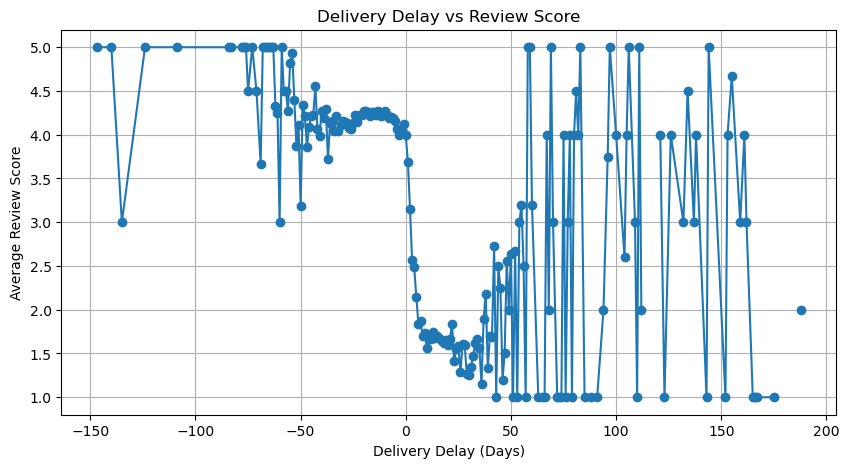

In [222]:
plt.figure(figsize=(10,5))

plt.plot(
    delay_review["delivery_delay_days"],
    delay_review["review_score"],
    marker="o"
)

plt.title("Delivery Delay vs Review Score")

plt.xlabel("Delivery Delay (Days)")

plt.ylabel("Average Review Score")

plt.grid(True)

plt.show()

Customer ratings generally decrease as delivery delays increase, showing that delivery performance influences customer satisfaction.

#### 5. Which orders took the longest to deliver?

In [226]:
master_df[
    [
        "order_id",
        "customer_state",
        "delivery_time_days"
    ]
].sort_values(
    by="delivery_time_days",
    ascending=False
).head(10)

,order_id,customer_state,delivery_time_days
23417,ca07593549f1816d26a572e06dc1eab6,ES,209.0
66581,1b3190b2dfa9d789e1f14c05b647a14a,RJ,208.0
73634,440d0d17af552815d15a9e41abe49359,PA,195.0
84056,2fb597c2f772eca01b1f5c561bf6cc7b,PI,194.0
106627,285ab9426d6982034523a855f55a885e,SE,194.0
46165,0f4519c5f1c541ddec9f21b3bddd533a,PI,194.0
13563,47b40429ed8cce3aee9199792275433f,SP,191.0
97345,2fe324febf907e3ea3f2aa9650869fa5,SP,189.0
65222,2d7561026d542c8dbd8f0daeadf67a43,SE,188.0
74421,437222e3fd1b07396f1d9ba8c15fba59,AP,187.0


A few orders experienced significantly longer delivery times compared to the overall average.

## Review Analysis

This section analyzes customer ratings and reviews to understand customer satisfaction and overall shopping experience.

#### 1. What is the average customer review score?

In [231]:
print(
    f"Average Review Score : {master_df['review_score'].mean():.2f}"
)

Average Review Score : 4.02


The average review score indicates the overall customer satisfaction with their shopping experience.

#### 2. How are review scores distributed?

In [237]:
review_distribution = (
    master_df["review_score"]
    .value_counts()
    .sort_index()
)

review_distribution

review_score
1.0    15428
2.0     4162
3.0     9894
4.0    22319
5.0    66343
Name: count, dtype: int64

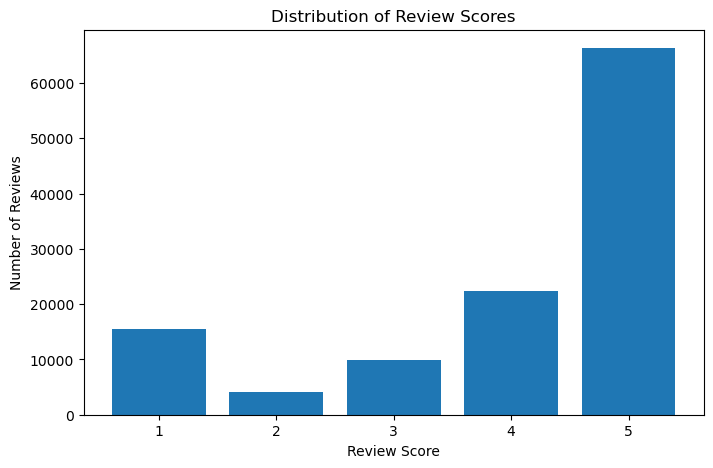

In [239]:
plt.figure(figsize=(8,5))

plt.bar(
    review_distribution.index,
    review_distribution.values
)

plt.title("Distribution of Review Scores")

plt.xlabel("Review Score")

plt.ylabel("Number of Reviews")

plt.show()

Most customers gave higher ratings, showing a generally positive shopping experience.

#### 3. Which product categories receive the highest ratings?

In [245]:
category_reviews = (
    master_df.groupby("product_category_name_english")["review_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

category_reviews

,product_category_name_english,review_score
0,cds_dvds_musicals,4.642857
1,fashion_childrens_clothes,4.500000
2,books_general_interest,4.438503
3,books_imported,4.419355
4,flowers,4.419355
5,costruction_tools_tools,4.415842
6,books_technical,4.375465
7,food_drink,4.324138
8,small_appliances_home_oven_and_coffee,4.320513
9,luggage_accessories,4.295945


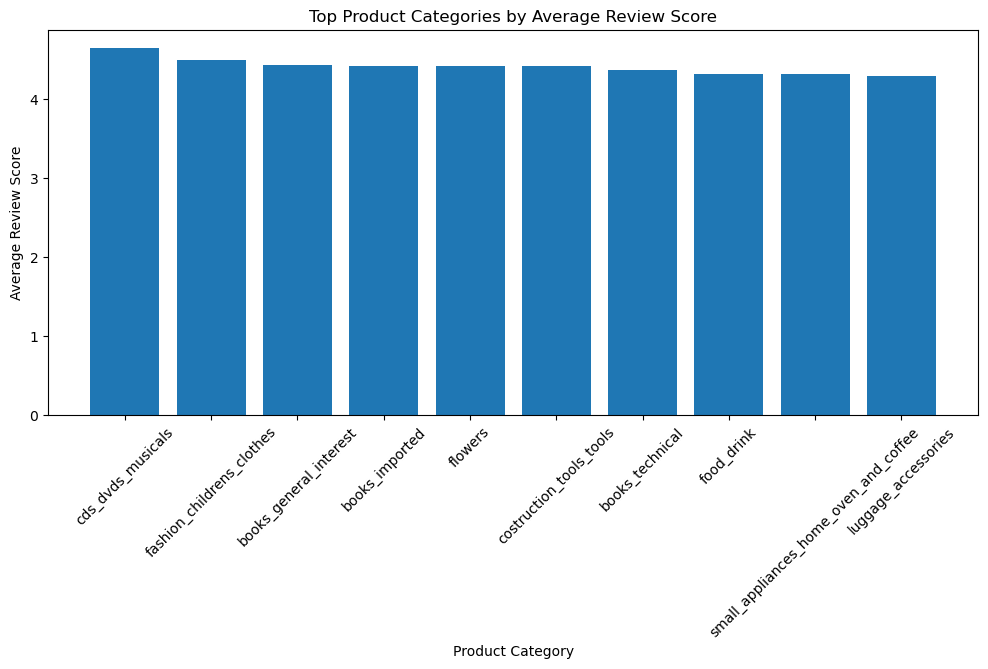

In [247]:
plt.figure(figsize=(12,5))

plt.bar(
    category_reviews["product_category_name_english"],
    category_reviews["review_score"]
)

plt.xticks(rotation=45)

plt.title("Top Product Categories by Average Review Score")

plt.xlabel("Product Category")

plt.ylabel("Average Review Score")

plt.show()

Some product categories consistently receive higher customer ratings, indicating better customer satisfaction.

## Seller Analysis

This section analyzes seller performance based on revenue and order volume.

#### 1. Which sellers generated the highest revenue?

In [254]:
seller_sales = (
    master_df.groupby("seller_id")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

seller_sales

,seller_id,price
0,53243585a1d6dc2643021fd1853d8905,244627.55
1,4869f7a5dfa277a7dca6462dcf3b52b2,237867.23
2,4a3ca9315b744ce9f8e9374361493884,215825.77
3,fa1c13f2614d7b5c4749cbc52fecda94,203984.22
4,7c67e1448b00f6e969d365cea6b010ab,199688.11
5,7e93a43ef30c4f03f38b393420bc753a,182878.17
6,da8622b14eb17ae2831f4ac5b9dab84a,171784.57
7,7a67c85e85bb2ce8582c35f2203ad736,150749.79
8,1025f0e2d44d7041d6cf58b6550e0bfa,143675.53
9,955fee9216a65b617aa5c0531780ce60,137405.00


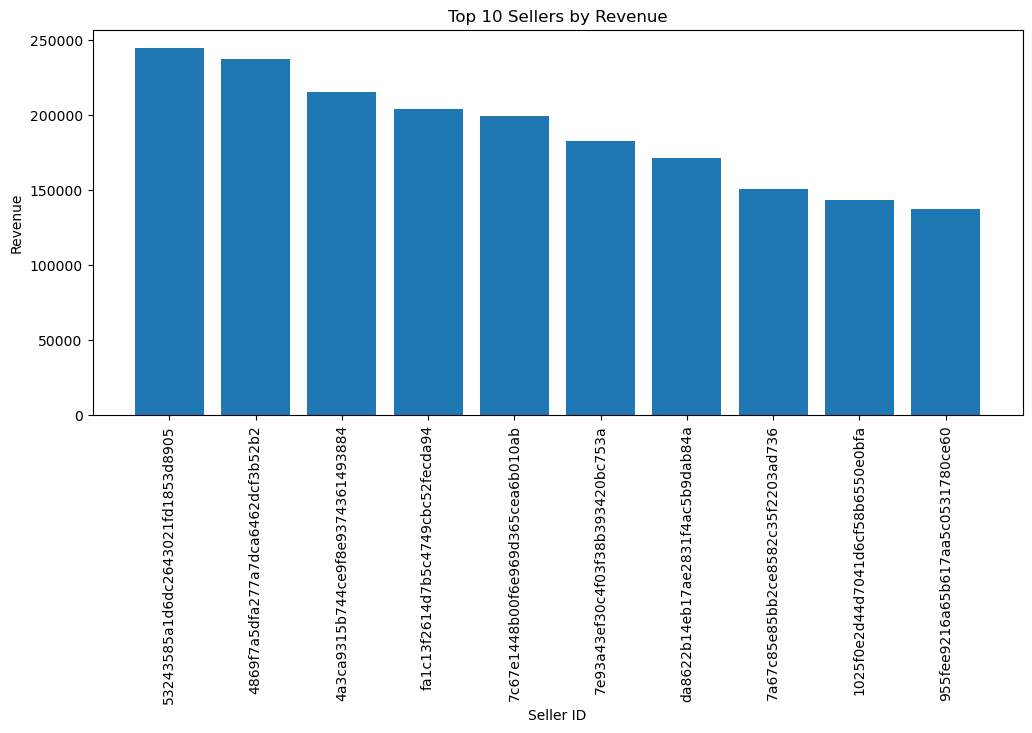

In [256]:
plt.figure(figsize=(12,5))

plt.bar(
    seller_sales["seller_id"],
    seller_sales["price"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Sellers by Revenue")

plt.xlabel("Seller ID")

plt.ylabel("Revenue")

plt.show()

A small number of sellers contribute a significant share of total revenue.

#### 2. Which sellers received the highest number of orders?

In [262]:
seller_orders = (
    master_df.groupby("seller_id")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

seller_orders

,seller_id,order_id
0,6560211a19b47992c3666cc44a7e94c0,1854
1,4a3ca9315b744ce9f8e9374361493884,1806
2,cc419e0650a3c5ba77189a1882b7556a,1706
3,1f50f920176fa81dab994f9023523100,1404
4,da8622b14eb17ae2831f4ac5b9dab84a,1314
5,955fee9216a65b617aa5c0531780ce60,1287
6,7a67c85e85bb2ce8582c35f2203ad736,1160
7,ea8482cd71df3c1969d7b9473ff13abc,1146
8,4869f7a5dfa277a7dca6462dcf3b52b2,1132
9,3d871de0142ce09b7081e2b9d1733cb1,1080


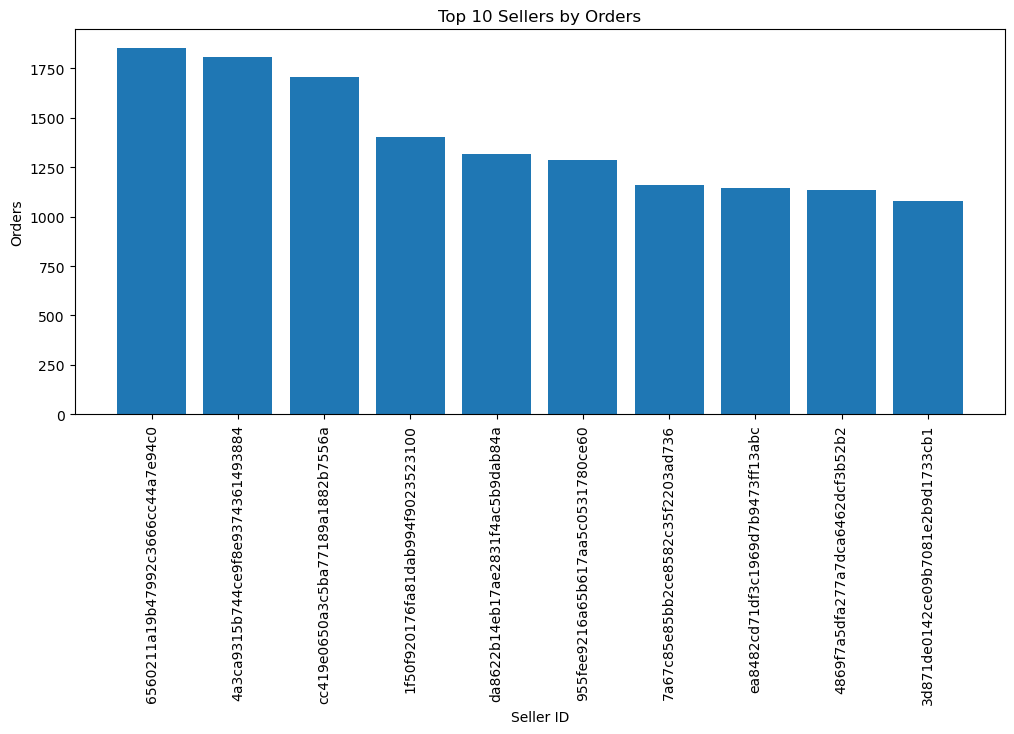

In [264]:
plt.figure(figsize=(12,5))

plt.bar(
    seller_orders["seller_id"],
    seller_orders["order_id"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Sellers by Orders")

plt.xlabel("Seller ID")

plt.ylabel("Orders")

plt.show()

The top sellers handle a larger number of customer orders compared to others.

## Seller Analysis

This section analyzes seller performance based on revenue and order volume.

#### 1. Which sellers generated the highest revenue?

In [272]:
top_sellers = (
    master_df.groupby("seller_id")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_sellers

seller_id
53243585a1d6dc2643021fd1853d8905    244627.55
4869f7a5dfa277a7dca6462dcf3b52b2    237867.23
4a3ca9315b744ce9f8e9374361493884    215825.77
fa1c13f2614d7b5c4749cbc52fecda94    203984.22
7c67e1448b00f6e969d365cea6b010ab    199688.11
7e93a43ef30c4f03f38b393420bc753a    182878.17
da8622b14eb17ae2831f4ac5b9dab84a    171784.57
7a67c85e85bb2ce8582c35f2203ad736    150749.79
1025f0e2d44d7041d6cf58b6550e0bfa    143675.53
955fee9216a65b617aa5c0531780ce60    137405.00
Name: price, dtype: float64

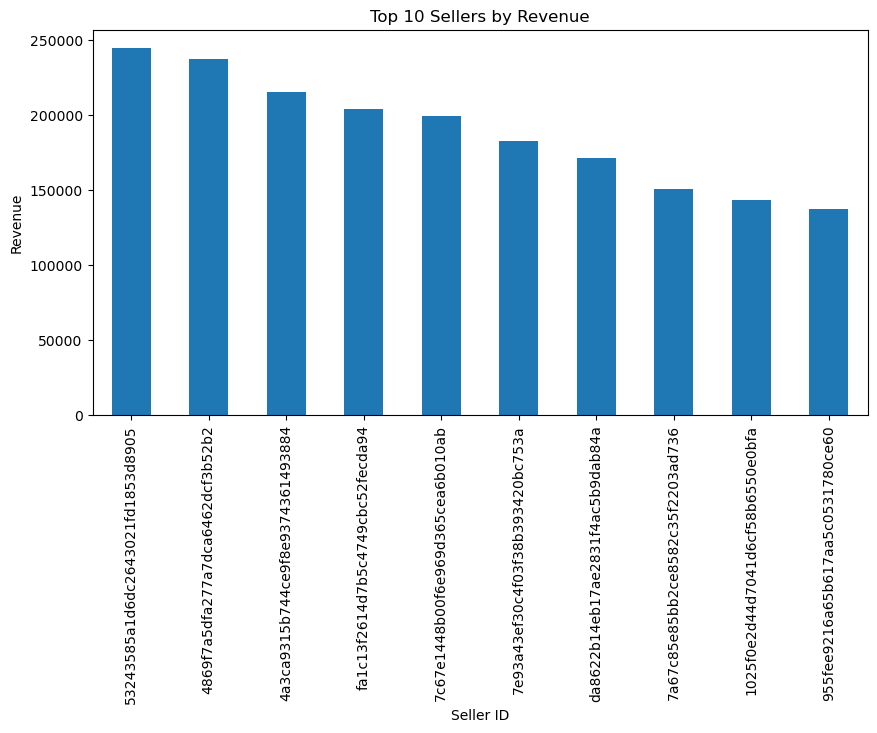

In [274]:
plt.figure(figsize=(10,5))

top_sellers.plot(kind="bar")

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Seller ID")
plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.show()

The top 10 sellers contribute a significant share of the total revenue.

#### 2. Which sellers received the highest number of orders?

In [278]:
seller_orders = (
    master_df.groupby("seller_id")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

seller_orders

seller_id
6560211a19b47992c3666cc44a7e94c0    1854
4a3ca9315b744ce9f8e9374361493884    1806
cc419e0650a3c5ba77189a1882b7556a    1706
1f50f920176fa81dab994f9023523100    1404
da8622b14eb17ae2831f4ac5b9dab84a    1314
955fee9216a65b617aa5c0531780ce60    1287
7a67c85e85bb2ce8582c35f2203ad736    1160
ea8482cd71df3c1969d7b9473ff13abc    1146
4869f7a5dfa277a7dca6462dcf3b52b2    1132
3d871de0142ce09b7081e2b9d1733cb1    1080
Name: order_id, dtype: int64

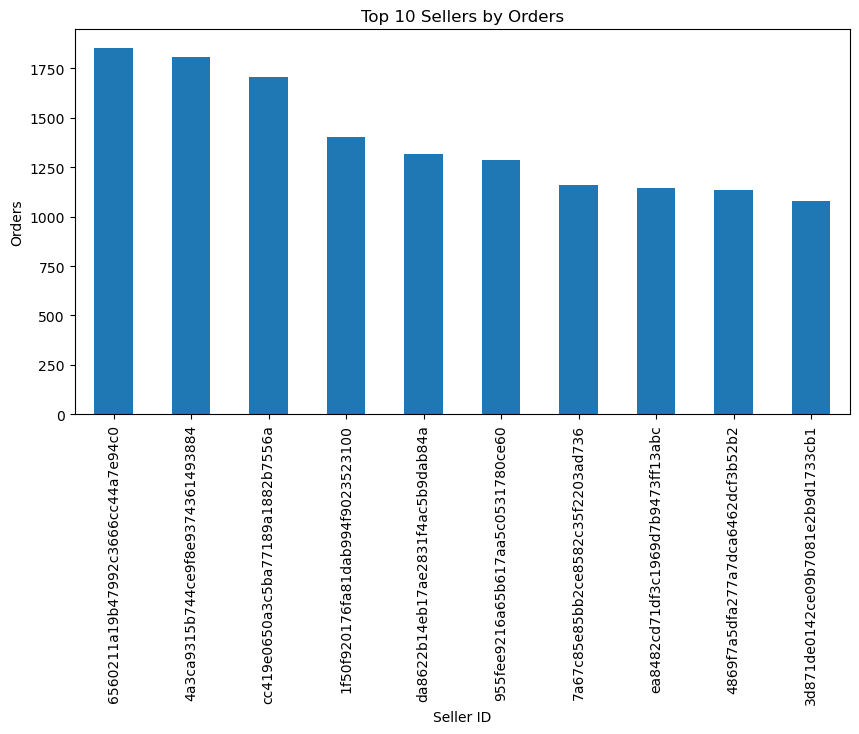

In [280]:
plt.figure(figsize=(10,5))

seller_orders.plot(kind="bar")

plt.title("Top 10 Sellers by Orders")
plt.xlabel("Seller ID")
plt.ylabel("Orders")

plt.xticks(rotation=90)

plt.show()

A small number of sellers handle the highest order volumes.

## Customer Review Analysis

This section analyzes customer ratings to understand customer satisfaction.

#### 1. What is the distribution of review scores?

In [285]:
review_counts = (
    master_df["review_score"]
    .value_counts()
    .sort_index()
)

review_counts

review_score
1.0    15428
2.0     4162
3.0     9894
4.0    22319
5.0    66343
Name: count, dtype: int64

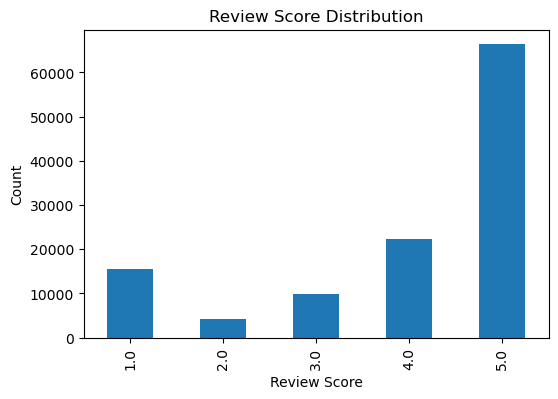

In [287]:
plt.figure(figsize=(6,4))

review_counts.plot(kind="bar")

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Count")

plt.show()

Most customers have given positive ratings, indicating good overall satisfaction.

#### 2. What is the average review score?

In [291]:
print(
    f"Average Review Score : {master_df['review_score'].mean():.2f}"
)

Average Review Score : 4.02


#### 3. Does delivery time affect review scores?

In [294]:
review_delivery = (
    master_df.groupby("review_score")["delivery_time_days"]
    .mean()
)

review_delivery

review_score
1.0    19.099992
2.0    15.381893
3.0    13.552435
4.0    11.778330
5.0    10.203253
Name: delivery_time_days, dtype: float64

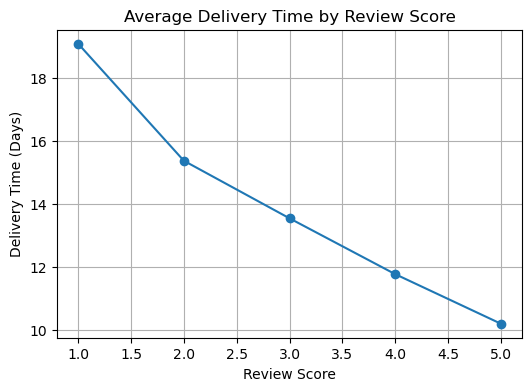

In [296]:
plt.figure(figsize=(6,4))

review_delivery.plot(marker="o")

plt.title("Average Delivery Time by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delivery Time (Days)")

plt.grid(True)

plt.show()

Lower review scores generally have higher average delivery times.

## Correlation Analysis

This section identifies relationships between numerical variables.

In [302]:
corr = master_df[
    [
        "price",
        "freight_value",
        "payment_value",
        "review_score",
        "delivery_time_days",
        "delivery_delay_days"
    ]
].corr()

corr

,price,freight_value,payment_value,review_score,delivery_time_days,delivery_delay_days
price,1.000000,0.415938,0.739236,-0.004492,0.061389,-0.003150
freight_value,0.415938,1.000000,0.373762,-0.037013,0.212870,-0.040571
payment_value,0.739236,0.373762,1.000000,-0.082343,0.060449,-0.019448
review_score,-0.004492,-0.037013,-0.082343,1.000000,-0.302750,-0.228449
delivery_time_days,0.061389,0.212870,0.060449,-0.302750,1.000000,0.598278
delivery_delay_days,-0.003150,-0.040571,-0.019448,-0.228449,0.598278,1.000000


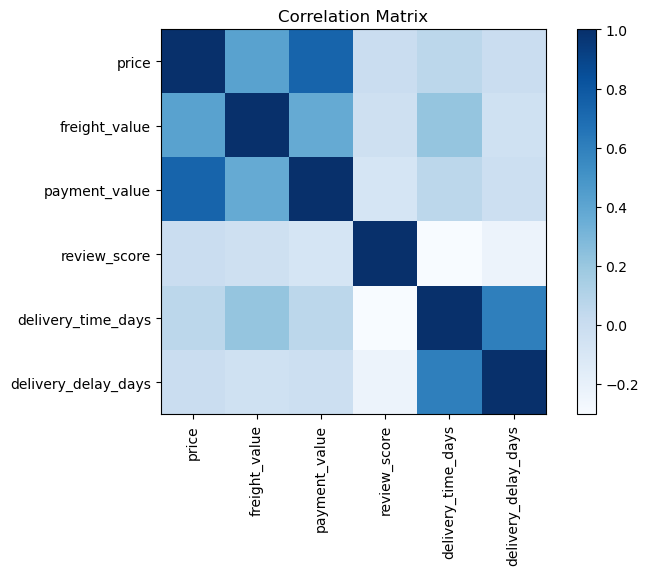

In [304]:
plt.figure(figsize=(8,5))

plt.imshow(corr, cmap="Blues")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

# Final Business Insights

• The business generated strong revenue across multiple product categories.

• Revenue showed steady growth over time with seasonal peaks.

• Credit cards were the most preferred payment method.

• A small group of sellers contributed a large portion of total sales.

• Most customer reviews were positive, indicating good customer satisfaction.

• Longer delivery times generally resulted in lower review scores.

• São Paulo had the highest concentration of customers.

• Household and furniture-related categories generated high sales.

• The average delivery time remained within the estimated delivery period for most orders.

• The prepared master dataset can now be used for dashboard creation and further business analysis.